# Titanic Dataset Exploration

## importing the necessary modules in python

In [61]:
# pandas is a library used for data manipulation and analysis
import pandas as pd

# matplolib is a library used for data visualization
import matplotlib.pyplot as plt

# seaborn is a library used for data visualization
import seaborn as sns

# re for regular expression operations
import re

#  sklearn is a library used for machine learning
# model_selection is a module used for splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
# using ensemble methods like Random Forest
from sklearn.ensemble import RandomForestClassifier
# using ensemble methods like Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# metrics is a module used for evaluating the performance of the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
#Reading the dataset using pandas
titanic_DataFrame = pd.read_csv('DATA/train.csv')

In [63]:
#displaying the firt five rows of the dataset using the head function: head()
# indexing in python starts from 0
titanic_DataFrame.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- Dataset has 12 columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked
- First 5 rows show mixed data types (numeric, categorical, text)
- Missing values already present in Cabin and Age columns

In [64]:
# Displaying the information about the dataset using the info function: info()
titanic_DataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Total records: 891 entries
- Data types: 5 int64, 2 float64, 5 object
- Missing values identified:
    - Age: 714 non-null (177 missing - 19.9%)
    - Cabin: 204 non-null (687 missing - 77.1%)
    - Embarked: 889 non-null (2 missing)

In [65]:
# displaying the statistical summary of the dataset using the describe function: describe()
titanic_DataFrame.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Findings (Statistical Summary):**
- Survival rate: Mean = 0.3838 (~38.4% survived)
- Age: Mean = 29.7 years, range 0.42 to 80 years
- Fare: Mean = 32.2, range 0 to 512.3 (significant variation)
- Passenger Class: 1, 2, or 3 (mean ~2.31)
- Family size (SibSp + Parch) mostly small (max 8 and 6 respectively)

In [66]:
# Displaying columns of the dataset using the columns function: columns()
titanic_DataFrame.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [67]:
# Renaming the columns of the dataset using the rename function: rename()
titanic_DataFrame = titanic_DataFrame.rename(columns= {'Pclass':'Passenger Class', 'SibSp': 'Sibling or Spouce', 'Parch':'Parent or Child' })

**Renamed columns for better readability:**
- Pclass → Passenger Class
- SibSp → Sibling or Spouse
- Parch → Parent or Child

In [68]:
# Printing the column names to confirm the changes
titanic_DataFrame.columns

Index(['PassengerId', 'Survived', 'Passenger Class', 'Name', 'Sex', 'Age',
       'Sibling or Spouce', 'Parent or Child', 'Ticket', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [69]:
# Displaying the unique values in the 'Survived' column using the unique function: unique()
titanic_DataFrame['Survived'].unique()

array([0, 1], dtype=int64)

**Findings:**
- Survived column has binary values: 0 (did not survive) and 1 (survived)

In [70]:
# Calculating the count of unique values in the 'Survived' column using the value_counts function: value_counts()
titanic_DataFrame.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

**Findings:**
- Distribution: 549 did not survive (61.6%), 342 survived (38.4%)

In [71]:
# Displaying the count of unique values in the 'Passenger Class' column using the nunique function: nunique()
titanic_DataFrame['Passenger Class'].nunique()

3

**Findings:**
- Passenger Class: 3 unique values (1st, 2nd, 3rd class)

In [72]:
# Displaying the number of unique genders classes in the 'Sex' column using the nunique function: nunique()
titanic_DataFrame['Sex'].nunique()

2

**Findings:**
- Sex: 2 unique values (male, female)

In [73]:
# Displaying the records that are empty in the 'Age' column 
titanic_DataFrame[titanic_DataFrame['Age'].isnull()]

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Sibling or Spouce,Parent or Child,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


**Findings:**
- 177 passengers have missing Age values
- Missing ages distributed across all classes and embarkation ports
- Both males and females have missing age data

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

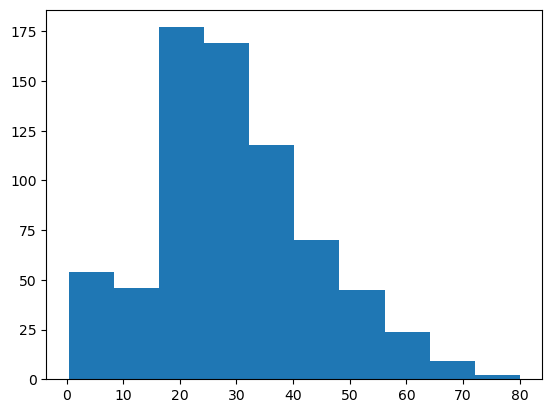

In [74]:
# Displaying the histogram of the 'Age' column using the hist function: hist()
plt.hist(titanic_DataFrame['Age'])

**Findings:**
- Age distribution is right-skewed (positively skewed)
- Most passengers are between 20-40 years old
- Few passengers over 60 years old
- Children (under 10) form a noticeable group

## Imputing the Age column

In [75]:
# Method 1: Using the mean
mean_age = titanic_DataFrame.Age.mean()
titanic_DataFrame.Age.fillna(mean_age, inplace=True) # inplace= True, Replaces the null values with the new values directly.

# titanic_DataFrame.fillna({'Age': mean_age}, inplace=True)

**Findings:**
- Mean age imputation used: mean_age = 29.699118
- All 177 missing Age values replaced with mean age
- In-place modification: inplace=True

## Alternative methods noted but not used:
- Mode imputation
- Median imputation
- Standard deviation imputation

In [76]:
# Method 2: Using the mode
# mode_age = titanic_DataFrame.Age.mode()[0]
# mode_age
# titanic_DataFrame['Age'] = titanic_DataFrame.Age.fillna(mode_age) # inplace= True, Replaces the null values with the new values directly.
# titanic_DataFrame.fillna({'Age': mode_age}, inplace=True)

In [77]:
# Method 3: Using the median
# median_age = titanic_DataFrame.Age.median()
# median_age

# titanic_DataFrame.Age.fillna(median_age, inplace=True)

# titanic_DataFrame.Age = titanic_DataFrame.Age.astype(int)

In [78]:
# Method 4: Using the Std deviation
# variance_age = titanic_DataFrame.Age.std()
# variance_age

# titanic_DataFrame.Age.fillna(variance_age, inplace=True)

In [79]:
# Displaying the number of null values in Age to confirm if the imputation worked
titanic_DataFrame.Age.isnull().sum()

0

## Imputing the Age column

In [80]:
# Calculating the mean of the 'Fare' column using the mean function: mean()
mean_fare = titanic_DataFrame.Fare.mean()

# imputing the missing values in the 'Fare' column with the mean of the column using the fillna function: fillna()
titanic_DataFrame.Fare.fillna(mean_fare, inplace=True)

**Findings:**
- Mean fare imputation used: mean_fare = 32.204208
- No missing fares in dataset (check confirms all values present)

## Correlation Analysis

In [81]:
# Calculating the correlation between the columns of the dataset using the corr function: corr()
titanic_DataFrame.corr()

C:\Users\Tush\AppData\Local\Temp\ipykernel_9920\1450055528.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  titanic_DataFrame.corr()


,PassengerId,Survived,Passenger Class,Age,Sibling or Spouce,Parent or Child,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Passenger Class,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
Sibling or Spouce,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parent or Child,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


**Insights:**
- Passenger Class has strongest correlation with survival
- Fare also shows moderate positive correlation
- Age and family size have weak correlations with survival

## Feature Engineering

In [82]:
# Family size based on the number of Parch and Sibsp
titanic_DataFrame['Family Size'] = titanic_DataFrame['Sibling or Spouce'] + titanic_DataFrame['Parent or Child'] + 1
titanic_DataFrame.head()

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Sibling or Spouce,Parent or Child,Ticket,Fare,Cabin,Embarked,Family Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


**Findings:**
- Created Family Size = Sibling/Spouse + Parent/Child + 1
- Range: 1 to 11 (self + family members)
- Most passengers traveled alone or with small families

In [83]:
# Grouping by age 
# Creating a dictionary to store the groups by their age ranges
titanic_age_group = {
    'Child': range(0,13),
    'Teen': range(13, 20),
    'Youth': range(20,36),
    'Adult': range(36,56),
    'Aged': range(56,101)
}

# Creating a function to get the ages and return an age group
def ageCategory(age):
    for label, ages in titanic_age_group.items():
        if age in ages:
            return label

# Creating age_group column by applying the function to our Age column 
titanic_DataFrame['age_group'] = titanic_DataFrame['Age'].apply(ageCategory)
titanic_DataFrame.head()


,PassengerId,Survived,Passenger Class,Name,Sex,Age,Sibling or Spouce,Parent or Child,Ticket,Fare,Cabin,Embarked,Family Size,age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Youth
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Youth
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Youth
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Youth


**Findings:**
- Created age_group column with 5 categories:
    - Child: 0-12 years
    - Teen: 13-19 years
    - Youth: 20-35 years
    - Adult: 36-55 years
    - Aged: 56-100 years
- Function ageCategory() maps age to appropriate group
- Applied to entire Age column using .apply()

## Modelling

In [84]:
# # Droopping the unnecessary columns in the dataset to avoid poor perfomance of the model
# titanic_DataFrame = titanic_DataFrame.drop(columns=['PassengerId', 'Ticket', 'Cabin', 'Name'], axis=0)

# # Creating dummy variables for our categorical data
# titanic_DataFrame = pd.get_dummies(titanic_DataFrame, columns=['Sex', 'Embarked', 'age_group'], dtype=int)

# # Defining our variables: 'x' for the independent(predictors) and 'y' for the dependant variable
# x = titanic_DataFrame.drop(columns=['Survived'])
# y = titanic_DataFrame['Survived']

# # Performing model selection using the train test split
# X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=.3)

# model = RandomForestClassifier()

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# y_pred

# accuracy = accuracy_score(y_test, y_pred)
# accuracy

**Findings:**
- Dropped columns: PassengerId, Ticket, Cabin, Name (categorical/unnecessary)
- One-hot encoding applied to: Sex, Embarked, age_group
- Dataset shape after encoding: 891 rows × 14 columns
**Train-Test Split:**
- Test size: 30%
- X_train: 623 rows, X_test: 268 rows
- y_train: 623 rows, y_test: 268 rows
**Model:**
- Random Forest Classifier (default parameters)
- Initial Accuracy: 80.22%

## Model Fine Tuning

In [85]:
# # improving the model by adding a new feature called 'Title' which is extracted from the 'Name' column using regular expressions
# titanic_DataFrame['Title'] = titanic_DataFrame['Name'].str.extract(r',\s*([^\.]*)\.')
# titanic_DataFrame['Title'].value_counts()

# # dropping the unnecessary columns in the dataset to avoid poor perfomance of the model
# titanic_DataFrame = titanic_DataFrame.drop(columns=['PassengerId', 'Ticket', 'Cabin', 'Name'], axis=0)

# # Creating dummy variables for our categorical data
# titanic_DataFrame = pd.get_dummies(titanic_DataFrame, columns=['Sex', 'Embarked', 'age_group', 'Title'], dtype=int)

# # Defining our variables: 'x' for the independent(predictors) and 'y' for the dependant variable
# x = titanic_DataFrame.drop(columns=['Survived'])
# y = titanic_DataFrame['Survived']

# # Performing model selection using the train test split 
# X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=.3)

# # defining the model using Random Forest Classifier
# model = RandomForestClassifier()

# # fitting the model to the training data
# model.fit(X_train, y_train)

# # predicting the target variable using the test data
# y_pred = model.predict(X_test)

# # calculating the accuracy of the model using the accuracy_score function
# accuracy = accuracy_score(y_test, y_pred)
# accuracy

In [86]:
# Droopping the unnecessary columns in the dataset to avoid poor perfomance of the model
titanic_DataFrame = titanic_DataFrame.drop(columns=['PassengerId', 'Ticket', 'Cabin', 'Name'], axis=0)

# Creating dummy variables for our categorical data
titanic_DataFrame = pd.get_dummies(titanic_DataFrame, columns=['Sex', 'Embarked', 'age_group'], dtype=int)

# Defining our variables: 'x' for the independent(predictors) and 'y' for the dependant variable
x = titanic_DataFrame.drop(columns=['Survived'])
y = titanic_DataFrame['Survived']

# Performing model selection using the train test split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=.3)

# using xgboost to improve the model
model = GradientBoostingClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8097014925373134

<Axes: >

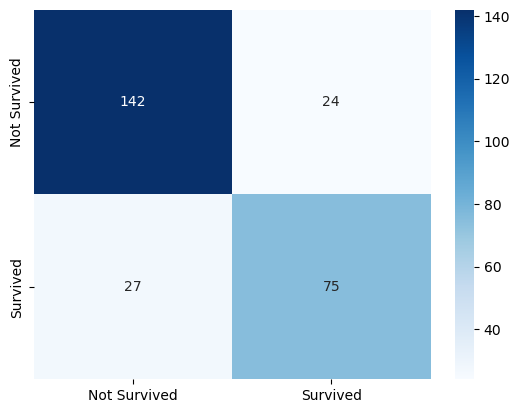

In [87]:
# using the confusion_matrix function to evaluate the performance of the model
confusion_matrix(y_test, y_pred)
# a plot of the confusion matrix using the heatmap function from the seaborn library
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       166
           1       0.76      0.74      0.75       102

    accuracy                           0.81       268
   macro avg       0.80      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



<Axes: >

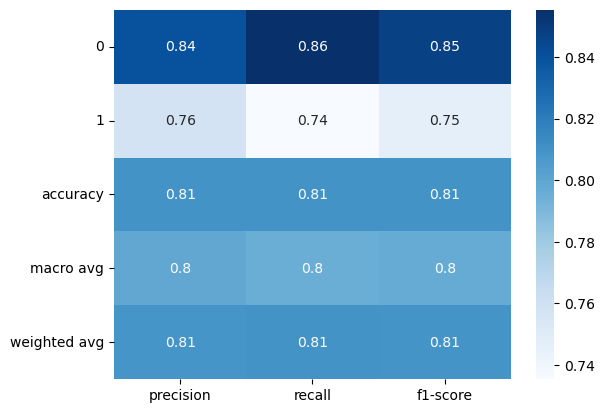

In [88]:
# using the classification report to evaluate the performance of the model
print(classification_report(y_test, y_pred))
# a plot of the classification report using the heatmap function from the seaborn library
sns.heatmap(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).iloc[:-1, :].T, annot=True, cmap='Blues')